In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Part 1 The Victim Model: Titanic dataset (public CSV file)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)
target_col = "survived"  

feature_cols = [
    "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked", "class", "who", "adult_male", "alone"
]
df = df[feature_cols + [target_col]]

df = df.dropna()

print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {list(df.columns[:-1])}")
print("\nTarget distribution:")
print(df[target_col].value_counts())


Dataset shape: (712, 12)

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']

Target distribution:
survived
0    424
1    288
Name: count, dtype: int64


In [3]:
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,survived
0,3,male,22.0,1,0,7.2500,S,Third,man,True,False,0
1,1,female,38.0,1,0,71.2833,C,First,woman,False,False,1
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,True,1
3,1,female,35.0,1,0,53.1000,S,First,woman,False,False,1
4,3,male,35.0,0,0,8.0500,S,Third,man,True,True,0


In [4]:
# Preprocess: one-hot encode categorical variables and scale numerical ones
def preprocess_titanic(df):
    """Preprocess the Titanic dataset for ML."""
    df = df.copy()

    y = df["survived"].astype(int)
    X = df.drop("survived", axis=1)

    categorical_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
    numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

    X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    feature_names = list(X.columns)

    return X.values, y.values, scaler, feature_names, numerical_cols, categorical_cols

X, y, scaler, feature_names, numerical_cols, categorical_cols = preprocess_titanic(df)

print(f"Preprocessed feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"  - Numerical features: {len(numerical_cols)}")
print(f"  - One-hot encoded features: {len(feature_names) - len(numerical_cols)}")
print(f"Class balance: {y.mean():.2%} positive (survived)")


Preprocessed feature matrix shape: (712, 20)
Number of features: 20
  - Numerical features: 5
  - One-hot encoded features: 15
Class balance: 40.45% positive (survived)


In [5]:
# Split data:

X_victim, X_temp, y_victim, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_attacker_pool, X_test, y_attacker_pool, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Victim training set: {len(X_victim)} samples")
print(f"Attacker's data pool: {len(X_attacker_pool)} samples")
print(f"Test set (evaluation): {len(X_test)} samples")

Victim training set: 427 samples
Attacker's data pool: 142 samples
Test set (evaluation): 143 samples


In [6]:
# Train the VICTIM model (attacker doesn't see this code!)
# Using a Random Forest - realistic "production" survival model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

victim_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

victim_model.fit(X_victim, y_victim)

victim_accuracy = accuracy_score(y_test, victim_model.predict(X_test))

print(f"Victim model test accuracy: {victim_accuracy:.4f}")
print(classification_report(y_test, victim_model.predict(X_test)))


Victim model test accuracy: 0.7273
              precision    recall  f1-score   support

           0       0.75      0.81      0.78        85
           1       0.69      0.60      0.64        58

    accuracy                           0.73       143
   macro avg       0.72      0.71      0.71       143
weighted avg       0.72      0.73      0.72       143



In [7]:
# Creating the Black-Box API

class BlackBoxAPI:

    def __init__(self, model, return_probabilities=True):
        self._model = model
        self.query_count = 0
        self.return_probabilities = return_probabilities

    def predict(self, X):
        X = np.atleast_2d(X)
        self.query_count += len(X)
        return self._model.predict(X)

    def predict_proba(self, X):
        if not self.return_probabilities:
            raise ValueError("This API does not return probabilities!")

        X = np.atleast_2d(X)
        self.query_count += len(X)
        return self._model.predict_proba(X)

    def get_query_count(self):
        return self.query_count

    def reset_query_count(self):
        self.query_count = 0


# Create the API 
api = BlackBoxAPI(victim_model, return_probabilities=True)

# Test it
test_input = X_test[0:3]

print(f"Query input shape: {test_input.shape}")
print(f"Predicted survival classes (0 = died, 1 = survived): {api.predict(test_input)}")
print(f"Predicted probabilities:\n{api.predict_proba(test_input)}")
print(f"\nQueries used so far: {api.get_query_count()}")


Query input shape: (3, 20)
Predicted survival classes (0 = died, 1 = survived): [0 1 1]
Predicted probabilities:
[[0.78 0.22]
 [0.09 0.91]
 [0.06 0.94]]

Queries used so far: 6


In [ ]:
#Part 2 Query Strategies: Stragey 1 used is random sampling
def random_sampling(n_samples, feature_bounds, binary_mask=None):
    """
    Generate random samples within feature bounds.

    For binary one-hot features, sample {0,1} instead of continuous values.

    Args:
        n_samples: Number of samples to generate
        feature_bounds: List of (min, max) tuples for each feature
        binary_mask: Boolean list/array indicating which features are binary (0/1)

    Returns:
        Array of shape (n_samples, n_features)
    """
    n_features = len(feature_bounds)
    samples = np.zeros((n_samples, n_features), dtype=float)

    for j, (min_val, max_val) in enumerate(feature_bounds):
        if binary_mask is not None and binary_mask[j]:
            # Sample 0/1 for one-hot/binary features
            samples[:, j] = np.random.randint(0, 2, size=n_samples)
        else:
            # Continuous uniform sampling within observed bounds
            samples[:, j] = np.random.uniform(min_val, max_val, size=n_samples)

    return samples


# Get feature bounds from the preprocessed Titanic data
feature_bounds = [(X[:, i].min(), X[:, i].max()) for i in range(X.shape[1])]

# Identify binary features (common after one-hot encoding)
# A feature is treated as binary if its values are only {0,1} in the dataset.
binary_mask = []
for i in range(X.shape[1]):
    unique_vals = np.unique(X[:, i])
    binary_mask.append(len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1}))

print("Feature bounds (first 5 features):")
for i in range(5):
    print(f"  {feature_names[i]}: [{feature_bounds[i][0]:.2f}, {feature_bounds[i][1]:.2f}]")

# Generate some random samples (Titanic)
random_samples = random_sampling(500, feature_bounds, binary_mask=binary_mask)

print(f"\nGenerated {len(random_samples)} random samples")
print(f"Sample shape: {random_samples.shape}")
print(f"Binary features detected: {sum(binary_mask)} / {len(binary_mask)}")

Feature bounds (first 5 features):
  pclass: [-1.48, 0.91]
  age: [-2.02, 3.48]
  sibsp: [-0.55, 4.82]
  parch: [-0.51, 6.52]
  fare: [-0.65, 9.03]

Generated 500 random samples
Sample shape: (500, 20)
Binary features detected: 15 / 20


In [9]:
#Part 2 Query Strategies: Stragey 2 used is Problem Domain Data

def domain_sampling(reference_data, n_samples, noise_scale=0.05, binary_mask=None):
    """
    Sample from reference data with optional noise.
    Simulates having access to similar (but not identical) Titanic data.

    Args:
        reference_data: Array of data points to sample from
        n_samples: Number of samples to generate
        noise_scale: Scale of Gaussian noise to add (0 = exact copies)
        binary_mask: Boolean mask for binary features (0/1 one-hot columns)

    Returns:
        Array of generated samples
    """
    # Sample with replacement from reference data
    indices = np.random.choice(len(reference_data), n_samples, replace=True)
    samples = reference_data[indices].copy()

    if noise_scale > 0:
        # Add small Gaussian noise
        noise = np.random.normal(0, noise_scale, samples.shape)
        samples = samples + noise

        # If we know which columns are binary, snap them back to 0/1
        if binary_mask is not None:
            samples[:, binary_mask] = (samples[:, binary_mask] > 0.5).astype(float)

    return samples


# Detect binary features
binary_mask = np.array([
    (len(np.unique(X[:, i])) <= 2) and set(np.unique(X[:, i])).issubset({0, 1})
    for i in range(X.shape[1])
], dtype=bool)

# Attacker uses their pool of similar Titanic data
domain_samples = domain_sampling(X_attacker_pool, 500, noise_scale=0.0, binary_mask=binary_mask)

print(f"Generated {len(domain_samples)} domain-based samples")

Generated 500 domain-based samples


In [10]:
#Part 2 Query Strategies: Stragey 3 used is Uncertainty Sampling/Active Learning

def uncertainty_sampling(api, candidate_pool, n_samples, batch_size=50):
    """
    Iteratively sample points where the Titanic victim model is most uncertain.

    Args:
        api: Black-box API to query
        candidate_pool: Pool of candidate samples to choose from (e.g., X_attacker_pool)
        n_samples: Total number of samples to select
        batch_size: How many samples to select each iteration

    Returns:
        selected_X: Selected samples (n_samples, n_features)
        selected_y: Victim model labels for those samples (0 = died, 1 = survived)
    """
    selected_X = []
    selected_y = []

    pool = candidate_pool.copy()
    remaining_idx = np.arange(len(pool))

    while len(selected_X) < n_samples and len(remaining_idx) > 0:
        # Current pool
        current_pool = pool[remaining_idx]

        # Get probabilities for all current pool samples
        probs = api.predict_proba(current_pool)

        # Uncertainty for binary classification:
        # highest when P(survived)=0.5, lowest near 0 or 1
        uncertainty = 1 - np.abs(probs[:, 1] - 0.5) * 2  # 1=most uncertain, 0=most certain

        # Select most uncertain samples
        n_select = min(batch_size, n_samples - len(selected_X), len(remaining_idx))
        uncertain_idx = np.argsort(uncertainty)[-n_select:]  # indices within current_pool

        # Grab those samples
        batch_X = current_pool[uncertain_idx]
        selected_X.extend(batch_X)

        # Query the black-box for labels (survival predictions)
        batch_labels = api.predict(batch_X)
        selected_y.extend(batch_labels)

        # Remove selected from remaining pool
        mask = np.ones(len(remaining_idx), dtype=bool)
        mask[uncertain_idx] = False
        remaining_idx = remaining_idx[mask]

    return np.array(selected_X), np.array(selected_y)


print("Uncertainty sampling function defined!")
# We'll use this in the comparison section

Uncertainty sampling function defined!


In [ ]:
#Part 3 Training the Substitute model

def extract_model(api, query_samples, substitute_model_class, **model_kwargs):
    """
    Perform a model extraction attack (Titanic version).

    Args:
        api: Black-box API to query (victim Titanic survival model)
        query_samples: Samples to use for querying (shape: [n_queries, n_features])
        substitute_model_class: Class of substitute model to train (e.g., LogisticRegression, RandomForestClassifier)
        **model_kwargs: Arguments for substitute model

    Returns:
        substitute: Trained substitute model
        stolen_labels: Labels returned by victim (0 = died, 1 = survived)
    """

    # Step 1: Query the API to get labels
    print(f"Querying API with {len(query_samples)} samples...")
    stolen_labels = api.predict(query_samples)

    # Step 2: Train substitute model on stolen data
    print(f"Training substitute model ({substitute_model_class.__name__})...")
    substitute = substitute_model_class(**model_kwargs)
    substitute.fit(query_samples, stolen_labels)

    print(f"Total queries used: {api.get_query_count()}")
    return substitute, stolen_labels


print("extract_model() function defined!")

extract_model() function defined!


In [12]:
# Reset API query count
api.reset_query_count()

# Let's try domain sampling first (more realistic for Titanic data)
n_queries = 1000
query_samples = domain_sampling(X_attacker_pool, n_queries, noise_scale=0.0)

# Perform the extraction attack!
# Note: Using a DIFFERENT architecture than the victim (Random Forest)
# Using Logistic Regression, works well for survival prediction

substitute_model, stolen_labels = extract_model(
    api,
    query_samples,
    LogisticRegression,
    max_iter=1000,
    random_state=42
)

print("\nTitanic model extraction complete!")


Querying API with 1000 samples...
Training substitute model (LogisticRegression)...
Total queries used: 1000

Titanic model extraction complete!


In [13]:
#Part 4: Evaluating the Attack

def evaluate_extraction(victim_api, substitute_model, X_eval, y_eval_true):
    """
    Evaluate the success of model extraction (Titanic version).

    Args:
        victim_api: The black-box API (for fidelity calculation)
        substitute_model: Our extracted model
        X_eval: Evaluation data
        y_eval_true: True labels (ground truth) (0 = died, 1 = survived)

    Returns:
        Dictionary of metrics
    """
    # Get predictions
    victim_preds = victim_api.predict(X_eval)
    substitute_preds = substitute_model.predict(X_eval)

    # Calculate metrics
    metrics = {
        # How accurate is our substitute vs ground truth?
        "substitute_accuracy": accuracy_score(y_eval_true, substitute_preds),

        # How accurate is the victim vs ground truth?
        "victim_accuracy": accuracy_score(y_eval_true, victim_preds),

        # FIDELITY: How often does substitute match victim?
        "fidelity": accuracy_score(victim_preds, substitute_preds),
    }

    return metrics


# Evaluate our extraction (Titanic)
print("=" * 50)
print("TITANIC EXTRACTION ATTACK EVALUATION")
print("=" * 50)

metrics = evaluate_extraction(api, substitute_model, X_test, y_test)

print(f"\nVictim Model Accuracy:      {metrics['victim_accuracy']:.4f}")
print(f"Substitute Model Accuracy:  {metrics['substitute_accuracy']:.4f}")
print(f"\n*** FIDELITY: {metrics['fidelity']:.4f} ***")
print(f"\n(Fidelity = how often substitute matches victim predictions)")
print(f"\nQueries used: {n_queries}")

TITANIC EXTRACTION ATTACK EVALUATION

Victim Model Accuracy:      0.7273
Substitute Model Accuracy:  0.7902

*** FIDELITY: 0.8531 ***

(Fidelity = how often substitute matches victim predictions)

Queries used: 1000


In [14]:
#Part 5: Comparing Query Strategies

def run_extraction_experiment(api, query_samples, strategy_name):
    """
    Run Titanic model extraction experiment with given query samples.
    """

    api.reset_query_count()

    # Get stolen labels from victim survival model
    stolen_labels = api.predict(query_samples)

    # Train substitute (Logistic Regression for survival prediction)
    substitute = LogisticRegression(max_iter=1000, random_state=42)
    substitute.fit(query_samples, stolen_labels)

    # Evaluate ( NOT counting these queries)
    victim_preds = victim_model.predict(X_test)   # direct access for eval only
    substitute_preds = substitute.predict(X_test)

    metrics = {
        "queries": len(query_samples),
        "strategy": strategy_name,
        "fidelity": accuracy_score(victim_preds, substitute_preds),
        "substitute_accuracy": accuracy_score(y_test, substitute_preds),
        "victim_accuracy": accuracy_score(y_test, victim_preds),
    }

    return metrics


# Running experiments with different query budgets
query_counts = [100, 250, 500, 1000, 2000, 5000]
results = []

print("Running Titanic extraction experiments...\n")

for n in query_counts:
    print(f"Testing with {n} queries...")

    # Random sampling
    random_samples = random_sampling(n, feature_bounds, binary_mask=binary_mask)
    r = run_extraction_experiment(api, random_samples, "Random")
    results.append(r)

    # Domain-based sampling
    domain_samples = domain_sampling(X_attacker_pool, n, noise_scale=0.0, binary_mask=binary_mask)
    r = run_extraction_experiment(api, domain_samples, "Domain")
    results.append(r)

print("\nTitanic experiments complete!")

Running Titanic extraction experiments...

Testing with 100 queries...
Testing with 250 queries...
Testing with 500 queries...
Testing with 1000 queries...
Testing with 2000 queries...
Testing with 5000 queries...

Titanic experiments complete!


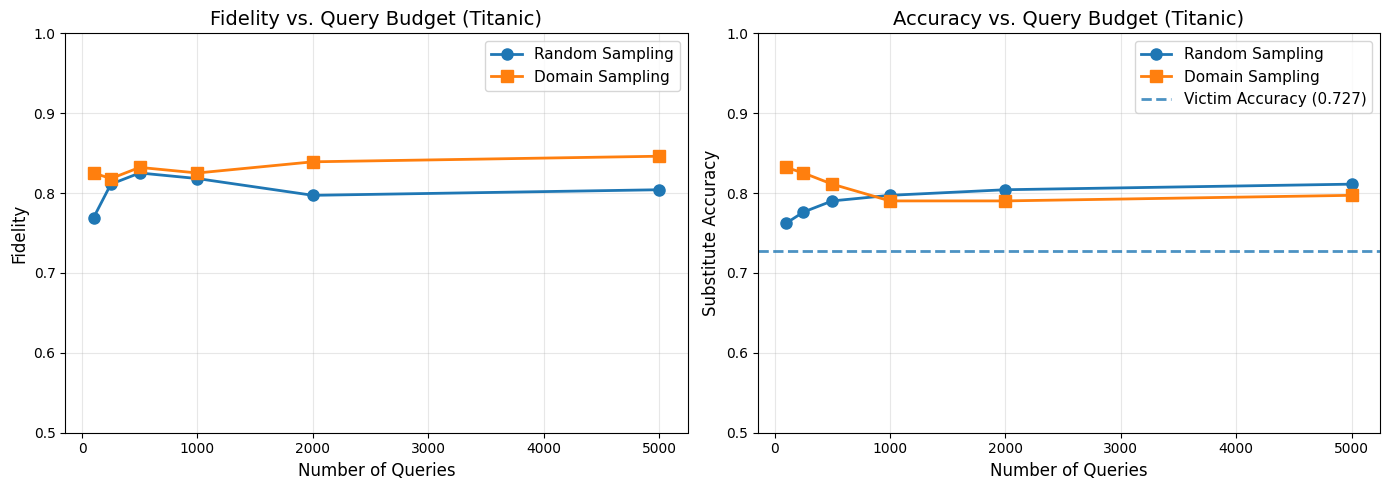

In [15]:
import matplotlib.pyplot as plt

# Prepare data for plotting
random_results = [r for r in results if r["strategy"] == "Random"]
domain_results = [r for r in results if r["strategy"] == "Domain"]

# Sort by query count
random_results = sorted(random_results, key=lambda x: x["queries"])
domain_results = sorted(domain_results, key=lambda x: x["queries"])

# Get victim accuracy (should be the same across runs)
victim_accuracy = results[0]["victim_accuracy"]

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Fidelity:
ax1 = axes[0]
ax1.plot(
    [r["queries"] for r in random_results],
    [r["fidelity"] for r in random_results],
    "o-",
    label="Random Sampling",
    linewidth=2,
    markersize=8
)
ax1.plot(
    [r["queries"] for r in domain_results],
    [r["fidelity"] for r in domain_results],
    "s-",
    label="Domain Sampling",
    linewidth=2,
    markersize=8
)
ax1.set_xlabel("Number of Queries", fontsize=12)
ax1.set_ylabel("Fidelity", fontsize=12)
ax1.set_title("Fidelity vs. Query Budget (Titanic)", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.0)

#Plot Accuracy:
ax2 = axes[1]
ax2.plot(
    [r["queries"] for r in random_results],
    [r["substitute_accuracy"] for r in random_results],
    "o-",
    label="Random Sampling",
    linewidth=2,
    markersize=8
)
ax2.plot(
    [r["queries"] for r in domain_results],
    [r["substitute_accuracy"] for r in domain_results],
    "s-",
    label="Domain Sampling",
    linewidth=2,
    markersize=8
)
ax2.axhline(
    y=victim_accuracy,
    linestyle="--",
    label=f"Victim Accuracy ({victim_accuracy:.3f})",
    alpha=0.8,
    linewidth=2
)
ax2.set_xlabel("Number of Queries", fontsize=12)
ax2.set_ylabel("Substitute Accuracy", fontsize=12)
ax2.set_title("Accuracy vs. Query Budget (Titanic)", fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

In [16]:
# Print summary table (Titanic)

print("\n" + "=" * 75)
print("SUMMARY (Titanic): Query Strategy Comparison")
print("=" * 75)
print(f"{'Strategy':<10} {'Queries':<10} {'Fidelity':<12} {'Sub. Acc.':<12} {'vs Victim':<12}")
print("-" * 75)

# Sort results by strategy, then queries (cleaner output)
results_sorted = sorted(results, key=lambda r: (r["strategy"], r["queries"]))

for r in results_sorted:
    diff = r["substitute_accuracy"] - r["victim_accuracy"]
    diff_str = f"{diff:+.4f}"
    print(f"{r['strategy']:<10} {r['queries']:<10} {r['fidelity']:<12.4f} {r['substitute_accuracy']:<12.4f} {diff_str:<12}")

print("\n** Key Insight: Domain sampling usually achieves higher fidelity with fewer queries on Titanic! **")


SUMMARY (Titanic): Query Strategy Comparison
Strategy   Queries    Fidelity     Sub. Acc.    vs Victim   
---------------------------------------------------------------------------
Domain     100        0.8252       0.8322       +0.1049     
Domain     250        0.8182       0.8252       +0.0979     
Domain     500        0.8322       0.8112       +0.0839     
Domain     1000       0.8252       0.7902       +0.0629     
Domain     2000       0.8392       0.7902       +0.0629     
Domain     5000       0.8462       0.7972       +0.0699     
Random     100        0.7692       0.7622       +0.0350     
Random     250        0.8112       0.7762       +0.0490     
Random     500        0.8252       0.7902       +0.0629     
Random     1000       0.8182       0.7972       +0.0699     
Random     2000       0.7972       0.8042       +0.0769     
Random     5000       0.8042       0.8112       +0.0839     

** Key Insight: Domain sampling usually achieves higher fidelity with fewer queries 

In [17]:
# Part 6: Trying Different Substitute Architectures

# Using a fixed query budget and strategy (Titanic)
n_queries = 2000
query_samples = domain_sampling(X_attacker_pool, n_queries)
stolen_labels = victim_model.predict(query_samples)  # Get labels once

# Trying different substitute architectures
architectures = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    'MLP (Neural Net)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

print(f"Query budget: {n_queries} samples")
print("Victim model (Titanic): Random Forest (100 trees, depth 15)")
print("\n" + "="*60)
print(f"{'Substitute Architecture':<25} {'Fidelity':<12} {'Accuracy':<12}")
print("="*60)

for name, model in architectures.items():
    # Train substitute on stolen data
    model.fit(query_samples, stolen_labels)

    # Evaluate on Titanic test set
    victim_preds = victim_model.predict(X_test)
    sub_preds = model.predict(X_test)

    fidelity = accuracy_score(victim_preds, sub_preds)
    accuracy = accuracy_score(y_test, sub_preds)

    print(f"{name:<25} {fidelity:<12.4f} {accuracy:<12.4f}")

print(f"\nVictim model accuracy: {accuracy_score(y_test, victim_model.predict(X_test)):.4f}")

Query budget: 2000 samples
Victim model (Titanic): Random Forest (100 trees, depth 15)

Substitute Architecture   Fidelity     Accuracy    
Logistic Regression       0.8042       0.8252      
Decision Tree             0.8462       0.7692      
Random Forest             0.8881       0.7692      
MLP (Neural Net)          0.8951       0.7762      

Victim model accuracy: 0.7273


In [18]:
#Bonus: Defense via Output Pertrubation

class DefendedAPI(BlackBoxAPI):
    """
    Titanic black-box API with defensive output perturbation.
    Rounds confidence scores to reduce information leakage.
    """

    def __init__(self, model, precision=2):
        super().__init__(model, return_probabilities=True)
        self.precision = precision  # Decimal places to round to

    def predict_proba(self, X):
        probs = super().predict_proba(X)
        # Round probabilities to reduce precision
        return np.round(probs, self.precision)


# Compare defended vs undefended with a label-only extraction attack (Titanic)
print("Defense Demo (Titanic): Rounding probability outputs")
print("(Attacker only uses predicted labels, not probabilities)\n")
print("=" * 50)

# (Optional but recommended) Detect binary features once, if not already defined
binary_mask = np.array([
    (len(np.unique(X[:, i])) <= 2) and set(np.unique(X[:, i])).issubset({0, 1})
    for i in range(X.shape[1])
], dtype=bool)

for precision in [None, 2, 1, 0]:
    if precision is None:
        test_api = BlackBoxAPI(victim_model, return_probabilities=True)
        label = "No defense"
    else:
        test_api = DefendedAPI(victim_model, precision=precision)
        label = f"Round to {precision} decimals"

    # Run extraction (label-only: we only use predict(), not predict_proba())
    query_samples = domain_sampling(X_attacker_pool, 1000, noise_scale=0.0, binary_mask=binary_mask)
    stolen_labels = test_api.predict(query_samples)

    substitute = LogisticRegression(max_iter=1000, random_state=42)
    substitute.fit(query_samples, stolen_labels)

    fidelity = accuracy_score(victim_model.predict(X_test), substitute.predict(X_test))

    print(f"{label:<25} -> Fidelity: {fidelity:.4f}")

Defense Demo (Titanic): Rounding probability outputs
(Attacker only uses predicted labels, not probabilities)

No defense                -> Fidelity: 0.8531
Round to 2 decimals       -> Fidelity: 0.8252
Round to 1 decimals       -> Fidelity: 0.8252
Round to 0 decimals       -> Fidelity: 0.8322
